# Prostate Cancer Phosphorylation Analysis — Ankh Pipeline

This notebook adapts the LUAD EGFR NAT Ankh phosphoproteomics workflow to analyze phosphorylation in prostate cancer using the dataset:

- `/home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/prostate_phosphorylation_lncap_palbociclib_analysis/Filtered_data_Prostate_Palbocilib_Phospho.csv`

**Outline:**
1. Set Paths and Imports
2. Inspect Existing Ankh Workflow in LUAD EGFR NAT Directory
3. Load and Validate Prostate Phosphorylation Input Data
4. Replicate Feature Preparation Used in Ankh Workflow
5. Build/Load Ankh Embeddings for Phosphosite 15-mers
6. Assemble Modeling Table and Labels
7. Run Baseline Statistical Analysis and QC Checks
8. Train and Evaluate Predictive Models
9. Interpret Important Features and Site-Level Signals
10. Save Outputs (Tables, Figures, and Serialized Objects)

In [1]:
# 1. Set Paths and Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import torch

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Define directories
LUAD_ANKH_DIR = Path("/home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD")
PDMAS_DIR = Path("/home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response")
PROSTATE_DATA = PDMAS_DIR / "prostate_phosphorylation_lncap_palbociclib_analysis/Filtered_data_Prostate_Palbocilib_Phospho.csv"
RESULTS_DIR = PDMAS_DIR / "results_prostate_phospho_ankh"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"LUAD Ankh workflow dir: {LUAD_ANKH_DIR}")
print(f"Prostate data file: {PROSTATE_DATA}")
print(f"Results dir: {RESULTS_DIR}")

LUAD Ankh workflow dir: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD
Prostate data file: /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/prostate_phosphorylation_lncap_palbociclib_analysis/Filtered_data_Prostate_Palbocilib_Phospho.csv
Results dir: /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh


In [2]:
# 2. Inspect Existing Ankh Workflow in LUAD EGFR NAT Directory
from pprint import pprint
import os

# List all notebooks and scripts in the LUAD Ankh workflow directory
luad_files = sorted([f for f in os.listdir(LUAD_ANKH_DIR) if f.endswith('.ipynb') or f.endswith('.py')])
print("LUAD EGFR NAT Ankh workflow files:")
pprint(luad_files)

# (Optional) Extract key parameters from the main notebook (manual step or via nbformat if needed)
# For now, just summarize the file list for reference.

LUAD EGFR NAT Ankh workflow files:
['Ankh_Phospho_EGFR_clean_pipeline.ipynb',
 'ESM2_Phospho_EGFR_clean_pipeline.ipynb',
 'ProtT5_Phospho_EGFR_clean_pipeline.ipynb']


In [3]:
# 3. Load and Validate Prostate Phosphorylation Input Data
df = pd.read_csv(PROSTATE_DATA)
print(f"Loaded data shape: {df.shape}")
display(df.head())

# Check for required columns
required_cols = ["Sequence", "Site_15mer", "Site", "Residue_Match"]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"Missing columns: {missing}")
else:
    print("All required columns present.")

# Remove rows with missing or invalid 15-mer windows or sequences
df_clean = df.dropna(subset=["Sequence", "Site_15mer", "Site"]).copy()
print(f"After cleaning: {df_clean.shape[0]} rows remain.")

# Report missingness
def report_missingness(df):
    na_counts = df.isna().sum()
    print("Missing values per column:")
    print(na_counts[na_counts > 0])
report_missingness(df_clean)

Loaded data shape: (7973, 34)


,ID,Version,PMID_sentenceIndex,PMID,Sentence,Protein_uniport,Protein,protein_entry,PTM,gene_manual,...,Disease_category,Regulatory Class,Pattern,PTM-regulation,Disease-regulation,Status,Sequence,Site_15mer,Residue_Match,Actual_Residue
0,acc23736,202507,PRIDE title,PXD006561,CDK4/6 inhibitor resistance in prostate cancer,Q12774,Rho guanine nucleotide exchange factor 5,ARHG5_HUMAN,phosphorylation,ARHGEF5,...,Cancer,Enhancing,3,ptm-down,disease-bad,Inferred,MEAEEAQRGASPPISAIEEFSIIPEAPMRSSQVSALGLEAQEDEDP...,ESRAEELSPAALSPS,True,S
1,acc23739,202507,PRIDE title,PXD006561,CDK4/6 inhibitor resistance in prostate cancer,Q12774,Rho guanine nucleotide exchange factor 5,ARHG5_HUMAN,phosphorylation,ARHGEF5,...,Cancer,Enhancing,3,ptm-down,disease-bad,Inferred,MEAEEAQRGASPPISAIEEFSIIPEAPMRSSQVSALGLEAQEDEDP...,ELSPAALSPSLEPIR,True,S
2,acc23743,202507,PRIDE title,PXD006561,CDK4/6 inhibitor resistance in prostate cancer,A0AAG2TJA1,Uncharacterized protein,YM012_HUMAN,phosphorylation,A0AAG2TJA1,...,Cancer,Enhancing,3,ptm-down,disease-bad,Inferred,MRRPSTASLTRTPSRASPTRMPSRASLKMTPFRASLTKMESTALLR...,SSLTRTPSMASLTRT,True,S
3,acc23745,202507,PRIDE title,PXD006561,CDK4/6 inhibitor resistance in prostate cancer,A0AAG2TJA1,Uncharacterized protein,YM012_HUMAN,phosphorylation,A0AAG2TJA1,...,Cancer,Enhancing,3,ptm-down,disease-bad,Inferred,MRRPSTASLTRTPSRASPTRMPSRASLKMTPFRASLTKMESTALLR...,ASLTRTPSMVSLKRS,True,S
4,acc23746,202507,PRIDE title,PXD006561,CDK4/6 inhibitor resistance in prostate cancer,A0FGR8,Extended synaptotagmin-2,ESYT2_HUMAN,phosphorylation,ESYT2,...,Cancer,Enhancing,3,ptm-down,disease-bad,Inferred,MTANRDAALSSHRHPGCAQRPRTPTFASSSQRRSAFGFDDGNFPGL...,HDLGRSSSSLLASPG,True,S


All required columns present.
After cleaning: 7973 rows remain.
Missing values per column:
Disease_fine    4245
Drug_info       7973
KW_info         7973
KW              7973
dtype: int64


In [4]:
# 4. Assign Class Labels for Modeling (PTM-regulation: ptm-up=1, ptm-down=0)

def label_ptm_regulation(val):
    if val == "ptm-up":
        return 1
    elif val == "ptm-down":
        return 0
    else:
        return np.nan

df_clean["Class"] = df_clean["PTM-regulation"].map(label_ptm_regulation)

# Report class distribution
class_counts = df_clean["Class"].value_counts(dropna=False)
print("Class label distribution (1=ptm-up, 0=ptm-down, NaN=other):")
print(class_counts)

df_model = df_clean.dropna(subset=["Class"]).copy()
print(f"Rows available for modeling: {df_model.shape[0]}")

Class label distribution (1=ptm-up, 0=ptm-down, NaN=other):
Class
0    7158
1     815
Name: count, dtype: int64
Rows available for modeling: 7973


## 5. Generate or Load Ankh Embeddings for Site 15-mers

This section will:
- Use the Ankh model to embed each Site_15mer sequence.
- Save embeddings to disk for reuse.
- If embeddings already exist, load them instead of recomputing.

**Note:** You must have the Ankh model and tokenizer installed and available.

In [5]:
# 5. Generate or Load Ankh Embeddings for Site 15-mers
# (Requires: ankh model + tokenizer installed, e.g. via pip or local repo)

import os

ANKH_EMBED_PATH = RESULTS_DIR / "ankh_site15mer_embeddings.npy"

try:
    from ankh import AnkhModel, AnkhTokenizer
except ImportError:
    print("[ERROR] Please install the Ankh model and tokenizer before running this cell.")
    ANKH_AVAILABLE = False
else:
    ANKH_AVAILABLE = True

if ANKH_AVAILABLE:
    if ANKH_EMBED_PATH.exists():
        print(f"Loading cached Ankh embeddings from {ANKH_EMBED_PATH}")
        X_emb = np.load(ANKH_EMBED_PATH)
    else:
        print("Generating Ankh embeddings for Site_15mer sequences...")
        model = AnkhModel.from_pretrained('ankh-base')
        tokenizer = AnkhTokenizer.from_pretrained('ankh-base')
        model.eval()
        model.to(device)
        
        site_windows = df_model["Site_15mer"].astype(str).tolist()
        batch_size = 64
        all_embeds = []
        for i in range(0, len(site_windows), batch_size):
            batch = site_windows[i:i+batch_size]
            tokens = tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
            tokens = {k: v.to(device) for k, v in tokens.items()}
            with torch.no_grad():
                outputs = model(**tokens)
                # Use [CLS] token or mean-pool as appropriate
                embeds = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeds.append(embeds)
        X_emb = np.concatenate(all_embeds, axis=0)
        np.save(ANKH_EMBED_PATH, X_emb)
        print(f"Saved embeddings to {ANKH_EMBED_PATH}")
else:
    X_emb = None

[ERROR] Please install the Ankh model and tokenizer before running this cell.


## 6. Train Classification Head on Ankh Embeddings

This section fits a simple classifier (logistic regression or MLP) to the Ankh embeddings to predict PTM-regulation (up vs down) from sequence context.

In [6]:
# 6. Train Classification Head on Ankh Embeddings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

if X_emb is not None:
    y = df_model["Class"].values.astype(int)
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_emb, y, test_size=0.2, random_state=SEED, stratify=y)
    
    # Fit logistic regression
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=3))
else:
    print("[ERROR] Ankh embeddings not available. Please run the previous cell successfully.")

[ERROR] Ankh embeddings not available. Please run the previous cell successfully.


## 7. Exploratory Data Analysis and Embedding Visualization

This section visualizes class distribution and projects Ankh embeddings using PCA and UMAP.

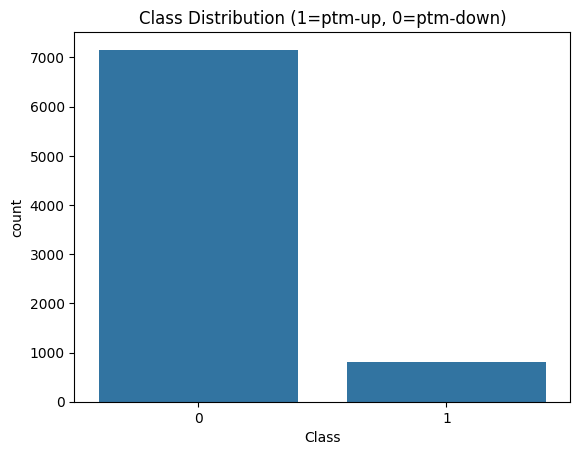

No embeddings available for PCA/UMAP (will be generated in later cells).


In [7]:

# 7. EDA: Class Distribution, PCA, UMAP
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Class distribution barplot
sns.countplot(x=df_model['Class'])
plt.title('Class Distribution (1=ptm-up, 0=ptm-down)')
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150)
plt.show()

# PCA projection of embeddings
if X_emb is not None:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_model['Class'], palette='Set1', alpha=0.7)
    plt.title('PCA of Ankh Embeddings')
    plt.savefig(RESULTS_DIR / 'ankh_pca.png', dpi=150)
    plt.show()

    # UMAP projection (optional, requires umap-learn)
    try:
        import umap
        reducer = umap.UMAP(random_state=SEED)
        X_umap = reducer.fit_transform(X_emb)
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=df_model['Class'], palette='Set1', alpha=0.7)
        plt.title('UMAP of Ankh Embeddings')
        plt.savefig(RESULTS_DIR / 'ankh_umap.png', dpi=150)
        plt.show()
    except ImportError:
        print('UMAP not installed; skipping UMAP plot.')
else:
    print('No embeddings available for PCA/UMAP (will be generated in later cells).')


## 8. MLP Classifier on Ankh Embeddings

This section trains a simple MLP (multi-layer perceptron) on the Ankh embeddings and compares its performance to logistic regression.

In [8]:
# 8. MLP Classifier on Ankh Embeddings
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, precision_recall_curve, auc

if X_emb is not None:
    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(X_emb, y, test_size=0.2, random_state=SEED, stratify=y)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32)

    class MLP(nn.Module):
        def __init__(self, input_dim, hidden_dim=128):
            super().__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.ReLU()
            self.fc2 = nn.Linear(hidden_dim, 1)
        def forward(self, x):
            x = self.fc1(x)
            x = self.relu(x)
            x = self.fc2(x)
            return x.squeeze(-1)

    model = MLP(X_train.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training loop
    n_epochs = 30
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t.to(device))
        loss = criterion(outputs, y_train_t.to(device))
        loss.backward()
        optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t.to(device)).cpu().numpy()
        y_pred = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()
        y_proba = torch.sigmoid(torch.tensor(logits)).numpy()
    print("MLP Accuracy:", accuracy_score(y_test, y_pred))
    print("MLP ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=3))

    # ROC and PR curves
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('MLP ROC Curve')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(recall, precision, label=f"AUC={auc(recall, precision):.3f}")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('MLP Precision-Recall Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'mlp_roc_pr_curves.png', dpi=150)
    plt.show()
else:
    print('No embeddings available for MLP classification.')

No embeddings available for MLP classification.


## 5A. Embed Full Protein Sequences with Ankh (HuggingFace Transformers)

This cell uses HuggingFace's AutoTokenizer/AutoModel to embed all unique protein sequences, caches the result, and prepares for window extraction.

In [9]:
# 5A. Embed Full Protein Sequences with Ankh (HuggingFace Transformers)
from transformers import AutoTokenizer, AutoModel, T5EncoderModel
import hashlib
from tqdm.auto import tqdm

MODEL_NAME = "ElnaggarLab/ankh-base"
MAX_LEN = 1024
BATCH_SIZE = 2
PROT_EMBED_CACHE = RESULTS_DIR / "ankh_full_protein_embeddings.npz"

# Deterministic protein identifier from sequence
sequence_to_id = lambda seq: hashlib.md5(seq.encode()).hexdigest()

# Ensure device is defined
try:
    device
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] device was not defined, set to: {device}")

unique_proteins = df_model[["Sequence"]].drop_duplicates().reset_index(drop=True)
print(f"Unique proteins to embed: {len(unique_proteins)}")

if PROT_EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {PROT_EMBED_CACHE} …")
    cache_data = np.load(PROT_EMBED_CACHE, allow_pickle=True)
    protein_embeddings = cache_data["embeddings"].item()
    print(f"Loaded {len(protein_embeddings)} embeddings from cache.")
else:
    print("Cache not found — running Ankh embedding (this may take a while)…")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    try:
        model = T5EncoderModel.from_pretrained(MODEL_NAME, trust_remote_code=True).to(device).eval()
    except Exception:
        model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True).to(device).eval()
    protein_embeddings = {}
    for i in tqdm(range(0, len(unique_proteins), BATCH_SIZE), desc="Embedding proteins"):
        batch_seqs = unique_proteins["Sequence"].iloc[i:i+BATCH_SIZE].tolist()
        pids = [sequence_to_id(s) for s in batch_seqs]
        tokens = tokenizer(batch_seqs, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
        input_ids = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)
        with torch.no_grad():
            # Use encoder for T5-based models
            if hasattr(model, "encoder"):
                outputs = model.encoder(input_ids=input_ids, attention_mask=attention_mask)
                hidden = outputs.last_hidden_state  # (B, L, D)
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                hidden = outputs.last_hidden_state  # (B, L, D)
        for j, pid in enumerate(pids):
            L = int(attention_mask[j].sum())
            protein_embeddings[pid] = hidden[j, :L].cpu()
    np.savez(PROT_EMBED_CACHE, embeddings=protein_embeddings)
    print(f"Embeddings cached to {PROT_EMBED_CACHE}")
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

EMBED_DIM = next(iter(protein_embeddings.values())).shape[1]
print(f"Embedding dim: {EMBED_DIM}")

/home/saishyam/ankh_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] device was not defined, set to: cuda
Unique proteins to embed: 2455
Loading cached embeddings from /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/ankh_full_protein_embeddings.npz …


Loaded 2455 embeddings from cache.
Embedding dim: 768


## 5B. Extract 15-mer Windows from Full-Protein Embeddings

This cell slices the 15-residue context window around each phosphosite from the full-protein embedding, matching the LUAD workflow.

In [10]:
# 5B. Extract 15-mer Windows from Full-Protein Embeddings
def extract_window_embedding(row, protein_embeddings, embed_dim):
    seq = row["Sequence"]
    pid = hashlib.md5(seq.encode()).hexdigest()
    start = int(row["win15_start"]) if "win15_start" in row else None
    end = int(row["win15_end"]) if "win15_end" in row else None
    if pid not in protein_embeddings or start is None or end is None:
        return np.full((15, embed_dim), np.nan)
    emb = protein_embeddings[pid]
    if emb.shape[0] < end:
        return np.full((15, embed_dim), np.nan)
    return emb[start:end].numpy()

# Apply to all rows
def build_window_embedding_matrix(df, protein_embeddings, embed_dim):
    X = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting 15-mer windows"):
        X.append(extract_window_embedding(row, protein_embeddings, embed_dim))
    X = np.stack(X)
    return X

# Example usage:
# X_win = build_window_embedding_matrix(df_model, protein_embeddings, EMBED_DIM)
# X_win_flat = X_win.reshape(X_win.shape[0], -1)  # Flatten for classifier input

In [11]:

import re
import hashlib
import numpy as np
from tqdm import tqdm

# --- Compute window positions from Site column (e.g. "Ser445" → 445, 1-indexed) ---
def parse_site_number(site_str):
    if pd.isna(site_str):
        return None
    m = re.search(r'(\d+)', str(site_str))
    return int(m.group(1)) if m else None

df_model["site_num"]    = df_model["Site"].apply(parse_site_number)
# 0-indexed center, 7-residue flanks on each side → slice [center-7 : center+8]
df_model["win15_start"] = df_model["site_num"].apply(lambda n: (n - 1 - 7)  if n is not None else np.nan)
df_model["win15_end"]   = df_model["site_num"].apply(lambda n: (n - 1 + 8)  if n is not None else np.nan)

n_valid = df_model["win15_start"].notna().sum()
print(f"Rows with valid site positions: {n_valid}/{len(df_model)}")

# --- Extract 15-mer window from full-protein embedding ---
def extract_window_embedding(row, protein_embeddings, embed_dim):
    seq = row["Sequence"]
    pid = hashlib.md5(seq.encode()).hexdigest()
    start = row["win15_start"]
    end   = row["win15_end"]
    if pd.isna(start) or pd.isna(end):
        return None
    start, end = int(start), int(end)
    if pid not in protein_embeddings:
        return None
    emb = protein_embeddings[pid]          # Tensor (L, D)
    if start < 0 or end > emb.shape[0]:
        return None
    window = emb[start:end].numpy()        # (15, D)
    if window.shape[0] != 15:
        return None
    return window

X_list, y_list = [], []
skipped = {"no_site": 0, "no_emb": 0, "boundary": 0}
for _, row in tqdm(df_model.iterrows(), total=len(df_model), desc="Extracting 15-mer windows"):
    if pd.isna(row["win15_start"]):
        skipped["no_site"] += 1
        continue
    w = extract_window_embedding(row, protein_embeddings, EMBED_DIM)
    if w is None:
        pid = hashlib.md5(row["Sequence"].encode()).hexdigest()
        if pid not in protein_embeddings:
            skipped["no_emb"] += 1
        else:
            skipped["boundary"] += 1
        continue
    X_list.append(w)
    y_list.append(int(row["Class"]))

if X_list:
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=int)
else:
    X = np.empty((0, 15, EMBED_DIM), dtype=np.float32)
    y = np.array([], dtype=int)

print(f"Final X shape: {X.shape}, y shape: {y.shape}")
print(f"Skipped — no site: {skipped['no_site']}, no embedding: {skipped['no_emb']}, boundary: {skipped['boundary']}")
if len(y) > 0:
    print(f"Class balance → PTM-down (0): {(y==0).sum()},  PTM-up (1): {(y==1).sum()}")


Rows with valid site positions: 7973/7973


Extracting 15-mer windows:   0%|                       | 0/7973 [00:00<?, ?it/s]

Extracting 15-mer windows:  24%|██▏      | 1930/7973 [00:00<00:00, 19289.26it/s]

Extracting 15-mer windows:  50%|████▌    | 4006/7973 [00:00<00:00, 20152.21it/s]

Extracting 15-mer windows:  76%|██████▊  | 6051/7973 [00:00<00:00, 20285.94it/s]

Extracting 15-mer windows: 100%|█████████| 7973/7973 [00:00<00:00, 20272.03it/s]

Final X shape: (6391, 15, 768), y shape: (6391,)
Skipped — no site: 0, no embedding: 0, boundary: 1582
Class balance → PTM-down (0): 5709,  PTM-up (1): 682


Train: (5112, 15, 768), Test: (1279, 15, 768)
All model classes defined.
Training: MaxPool MLP … 

AUROC=0.7898  AUPRC=0.4206  [3.8s]
Training: AttnPool MLP … 

AUROC=0.8077  AUPRC=0.5411  [3.8s]
Training: CenterOnly MLP … 

AUROC=0.8038  AUPRC=0.5553  [3.3s]
Training: Hybrid (C+Attn) … 

AUROC=0.8128  AUPRC=0.6151  [3.8s]
All models trained.


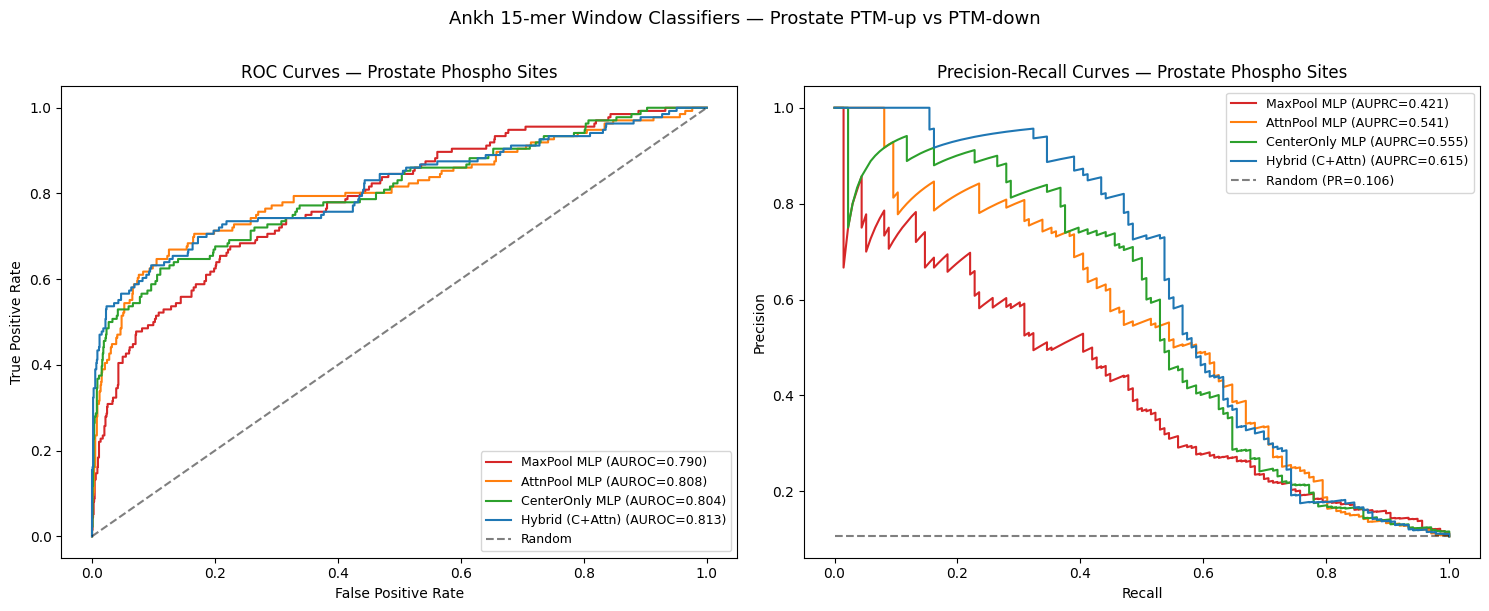

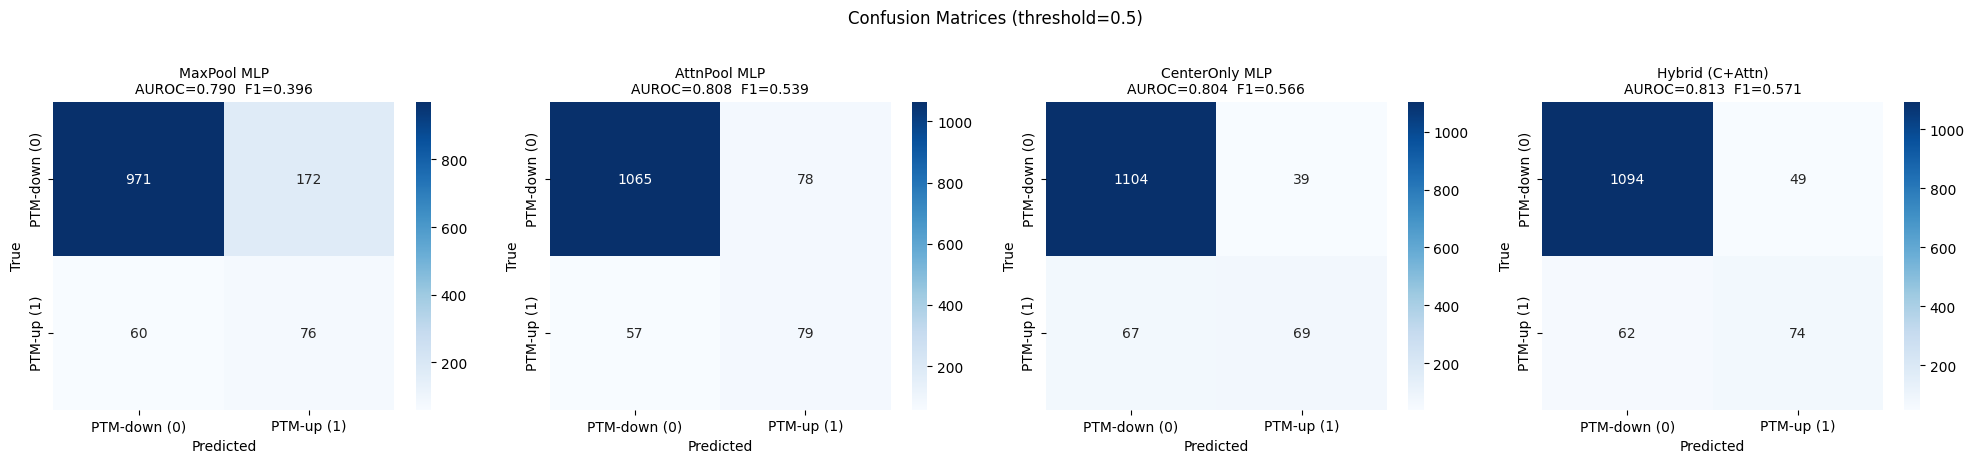

=== Model Performance Summary ===


,Model,AUROC,AUPRC,Precision,Recall,F1
0,Hybrid (C+Attn),0.8128,0.6151,0.6016,0.5441,0.5714
1,AttnPool MLP,0.8077,0.5411,0.5032,0.5809,0.5392
2,CenterOnly MLP,0.8038,0.5553,0.6389,0.5074,0.5656
3,MaxPool MLP,0.7898,0.4206,0.3065,0.5588,0.3958


PCA variance explained: 81.80%


/home/saishyam/ankh_env/lib64/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


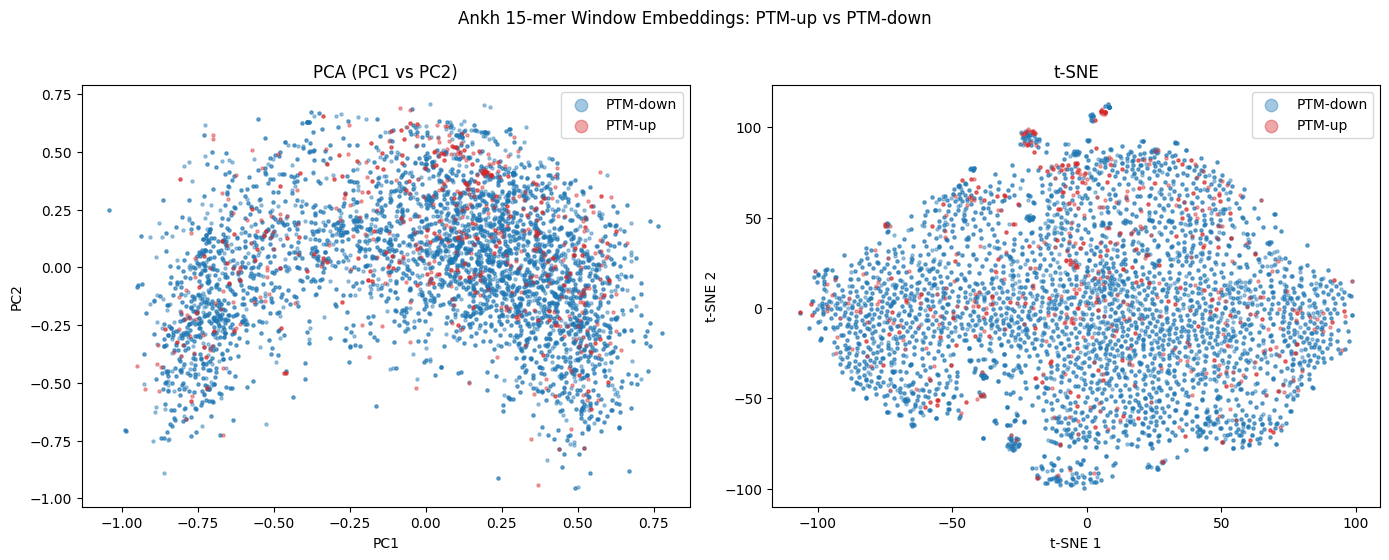

In [12]:

import time
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, confusion_matrix,
)
import torch.nn as nn
import torch.nn.functional as F

# --- Train/Test Split ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# --- Classification Heads ---
class MaxPool(nn.Module):
    def forward(self, x):
        return x.max(dim=1).values

class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Linear(dim, 1)
    def forward(self, x):
        scores  = self.attn(x).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)

class PhosphoMLP(nn.Module):
    def __init__(self, pool: nn.Module, dim: int):
        super().__init__()
        self.pool = pool
        self.mlp = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.mlp(self.pool(x)).squeeze(-1)

class CenterOnlyMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x[:, 7, :]).squeeze(-1)

class HybridMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn_pool = AttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        center  = x[:, 7, :]
        context = self.attn_pool(x)
        return self.classifier(torch.cat([center, context], dim=1)).squeeze(-1)

print("All model classes defined.")

# --- Training Loop ---
def train_and_eval(model, X_tr, y_tr, X_va, y_va, epochs=20, lr=1e-3, batch_size=64):
    model = model.to(device)
    pos_weight = torch.tensor((y_tr == 0).sum() / (y_tr == 1).sum(), dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
        ), batch_size=batch_size, shuffle=True)
    val_X = torch.tensor(X_va, dtype=torch.float32).to(device)
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(val_X)).cpu().numpy()
    roc = roc_auc_score(y_va, probs)
    pr  = average_precision_score(y_va, probs)
    return probs, roc, pr

# --- Train All Models ---
D = EMBED_DIM
models_to_train = {
    "MaxPool MLP":      PhosphoMLP(MaxPool(),       dim=D),
    "AttnPool MLP":     PhosphoMLP(AttentionPool(D), dim=D),
    "CenterOnly MLP":   CenterOnlyMLP(dim=D),
    "Hybrid (C+Attn)":  HybridMLP(dim=D),
}
results = {}
for name, model in models_to_train.items():
    print(f"Training: {name} …", end=" ", flush=True)
    t0 = time.time()
    probs, roc, pr = train_and_eval(model, X_train, y_train, X_test, y_test, epochs=20)
    elapsed = time.time() - t0
    results[name] = {"probs": probs, "roc_auc": roc, "pr_auc": pr}
    print(f"AUROC={roc:.4f}  AUPRC={pr:.4f}  [{elapsed:.1f}s]")
print("All models trained.")

# --- ROC & PR Curves ---
PALETTE = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
baseline_pr = (y_test == 1).mean()
for (name, res), color in zip(results.items(), PALETTE):
    probs = res["probs"]
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUROC={res['roc_auc']:.3f})", color=color)
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, label=f"{name} (AUPRC={res['pr_auc']:.3f})", color=color)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Prostate Phospho Sites")
axes[0].legend(loc="lower right", fontsize=9)
axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", alpha=0.5, label=f"Random (PR={baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Prostate Phospho Sites")
axes[1].legend(loc="upper right", fontsize=9)
plt.suptitle("Ankh 15-mer Window Classifiers — Prostate PTM-up vs PTM-down", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Confusion Matrices & Metrics ---
THRESHOLD = 0.5
metrics_rows = []
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    probs = res["probs"]
    preds = (probs >= THRESHOLD).astype(int)
    prec   = precision_score(y_test, preds, zero_division=0)
    rec    = recall_score(y_test, preds, zero_division=0)
    f1     = f1_score(y_test, preds, zero_division=0)
    roc    = res["roc_auc"]
    pr_auc = res["pr_auc"]
    metrics_rows.append({
        "Model":    name,
        "AUROC":    round(roc, 4),
        "AUPRC":    round(pr_auc, 4),
        "Precision": round(prec, 4),
        "Recall":   round(rec, 4),
        "F1":       round(f1, 4),
    })
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["PTM-down (0)", "PTM-up (1)"],
        yticklabels=["PTM-down (0)", "PTM-up (1)"],)
    ax.set_title(f"{name}\nAUROC={roc:.3f}  F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion Matrices (threshold=0.5)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
metrics_df = pd.DataFrame(metrics_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
print("=== Model Performance Summary ===")
display(metrics_df)

# --- Embedding Visualisation (PCA + t-SNE) ---
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
X_mean_pool = X.mean(axis=1)
pca = PCA(n_components=min(50, X_mean_pool.shape[0], X_mean_pool.shape[1]), random_state=SEED)
X_pca50 = pca.fit_transform(X_mean_pool)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.2%}")
X_pca2 = X_pca50[:, :2]
tsne = TSNE(n_components=2, perplexity=min(40, len(X_mean_pool) - 1), random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
label_colors = {1: "#d62728", 0: "#1f77b4"}
label_names  = {1: "PTM-up", 0: "PTM-down"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for label in [0, 1]:
    mask = y == label
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=5, alpha=0.4, color=label_colors[label], label=label_names[label], rasterized=True)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.4, color=label_colors[label], label=label_names[label], rasterized=True)
axes[0].set_title("PCA (PC1 vs PC2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=4)
axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(markerscale=4)
plt.suptitle("Ankh 15-mer Window Embeddings: PTM-up vs PTM-down", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/07_model_metrics_summary.csv


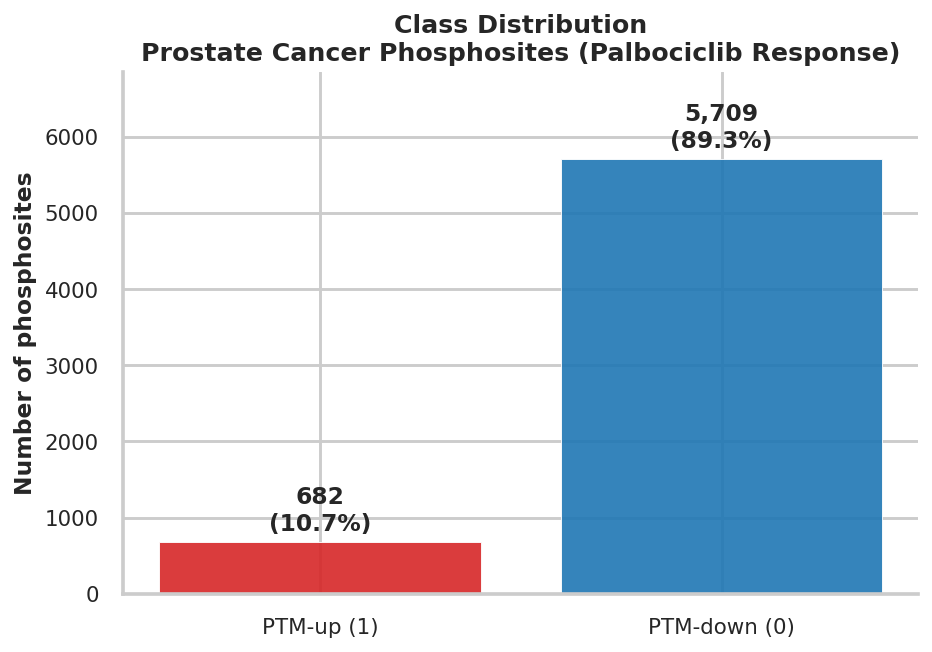

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/01_class_distribution.png


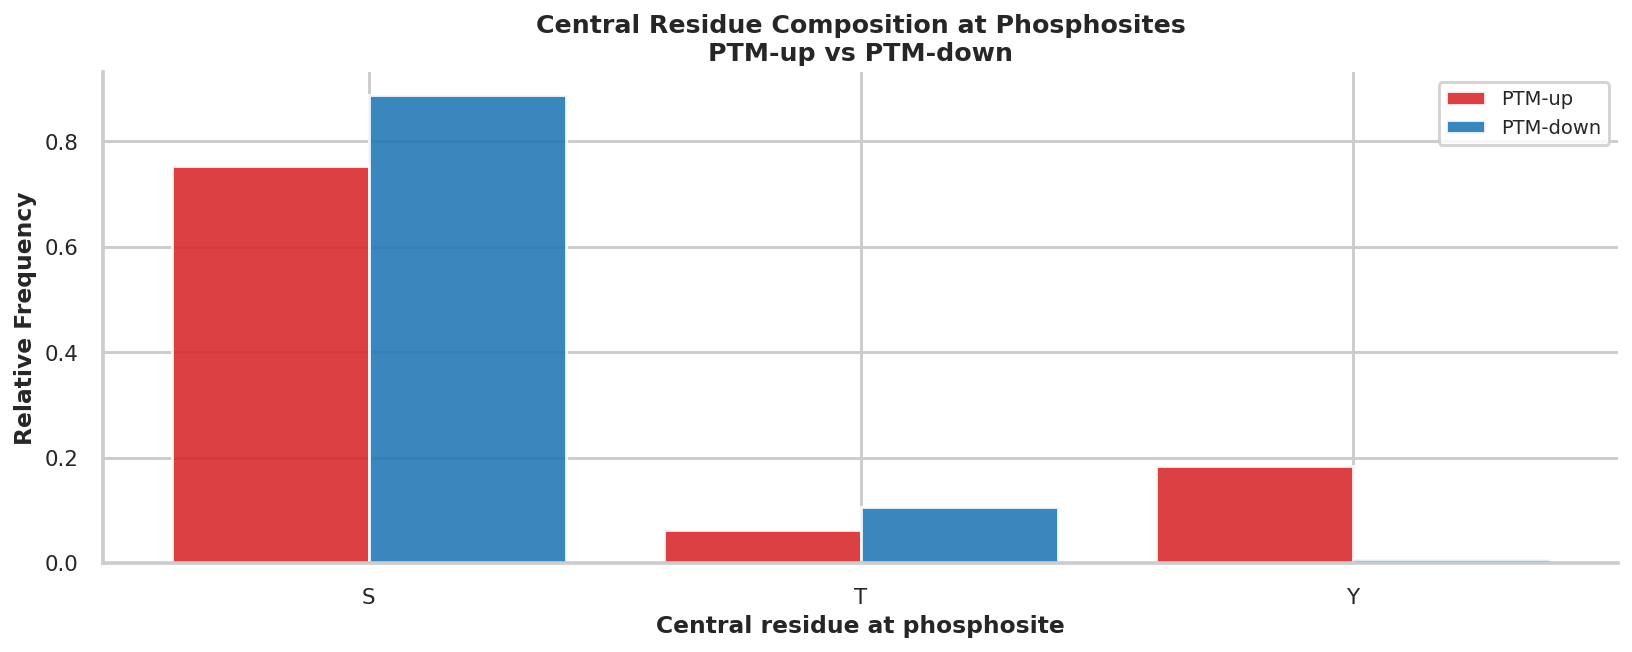

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/04_central_residue_composition.png


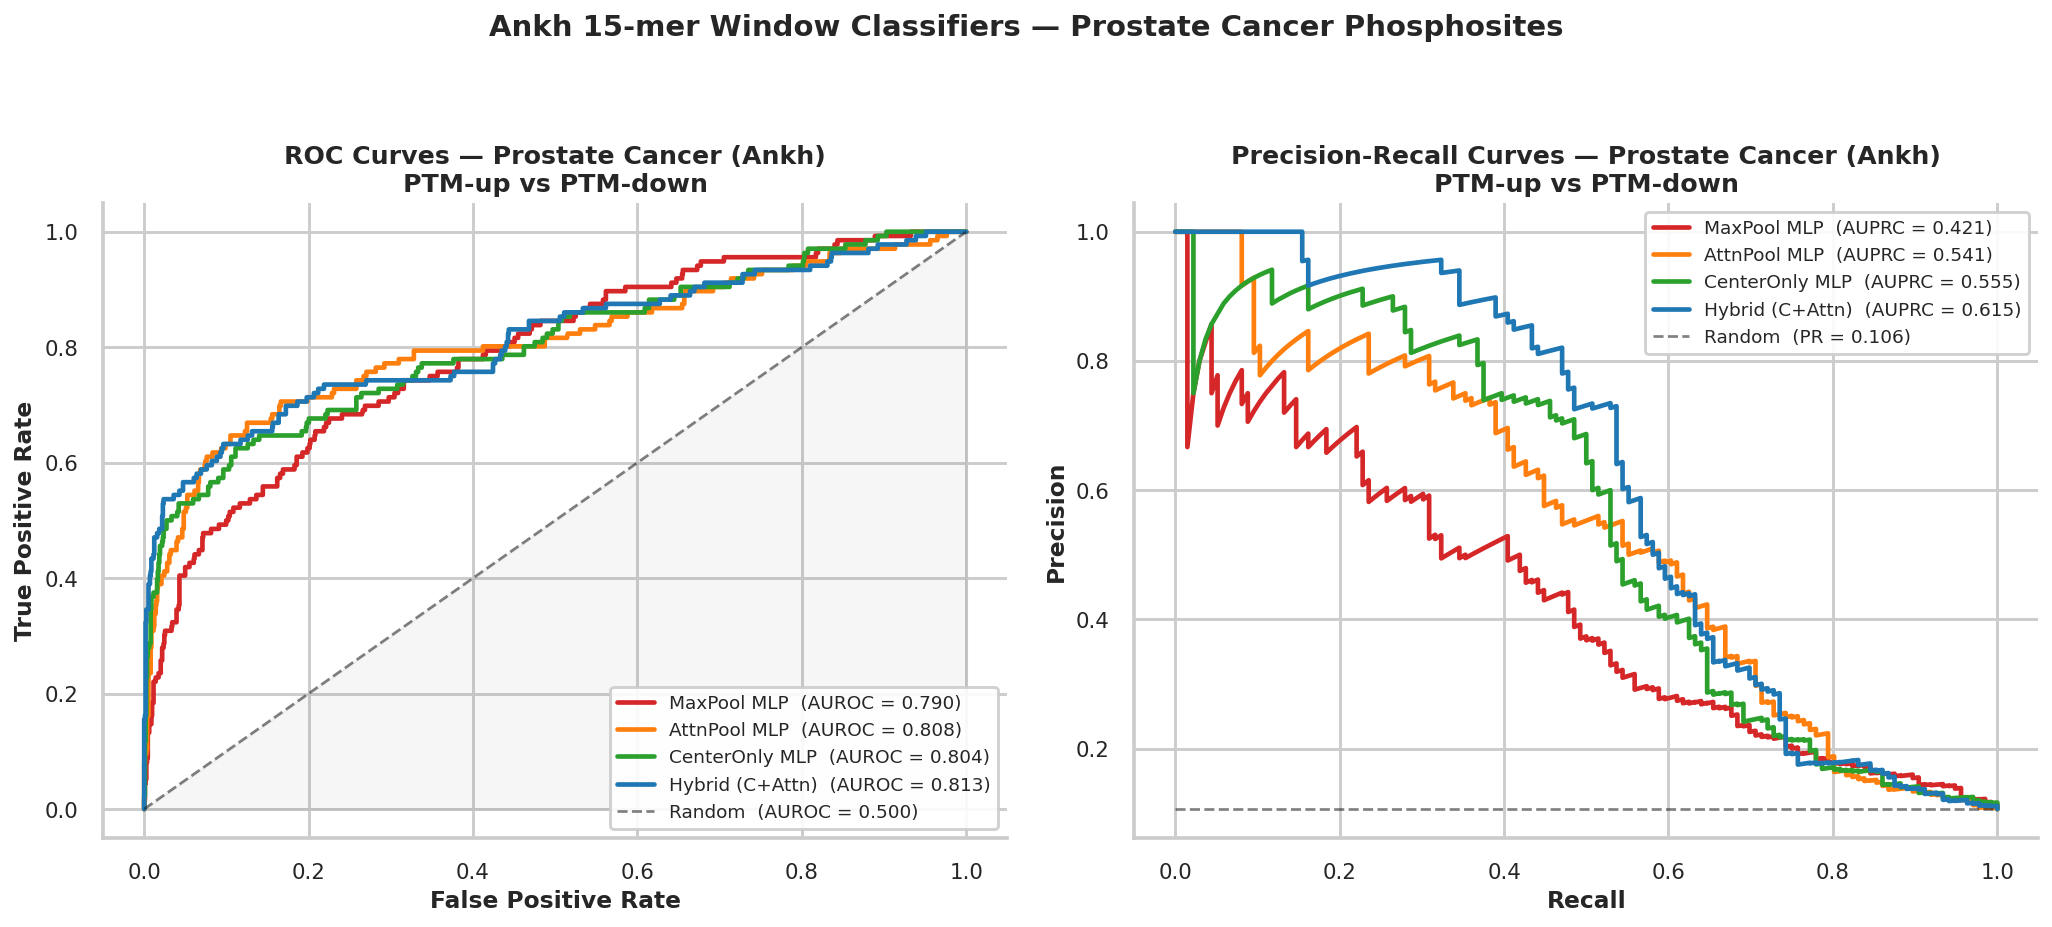

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/05_roc_pr_curves.png


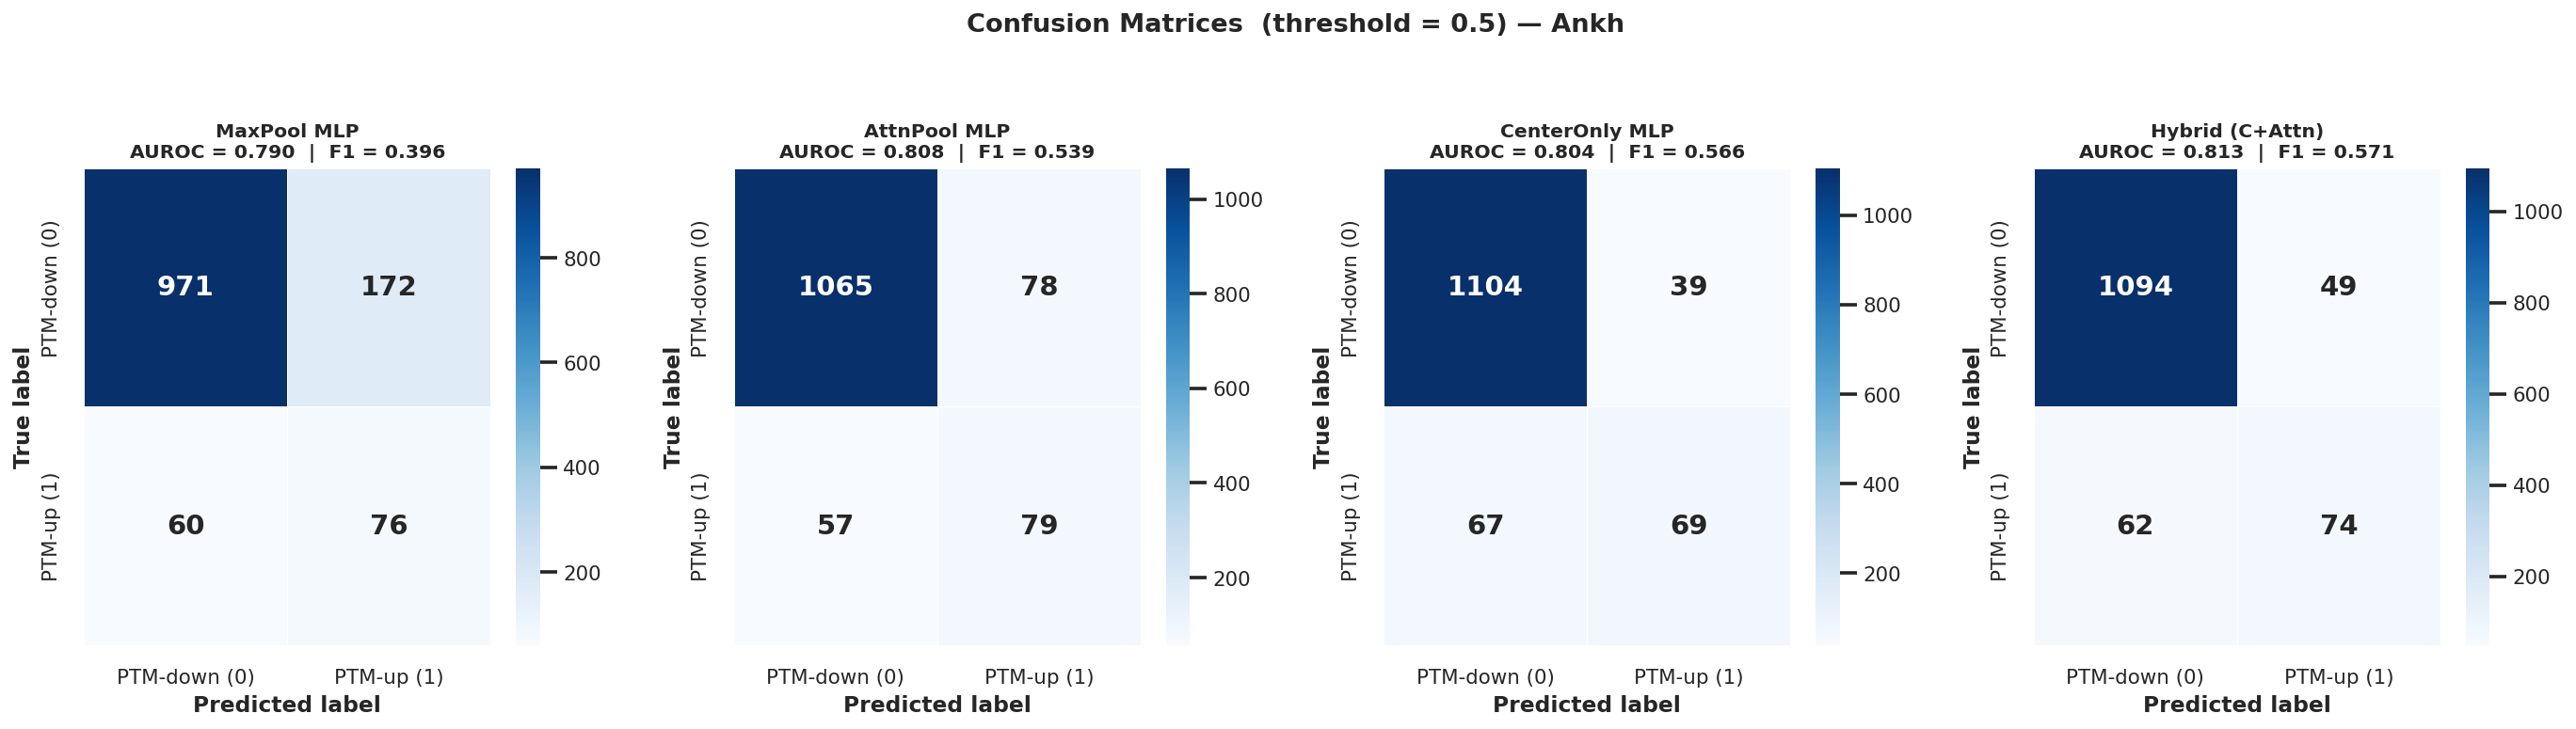

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/06_confusion_matrices.png


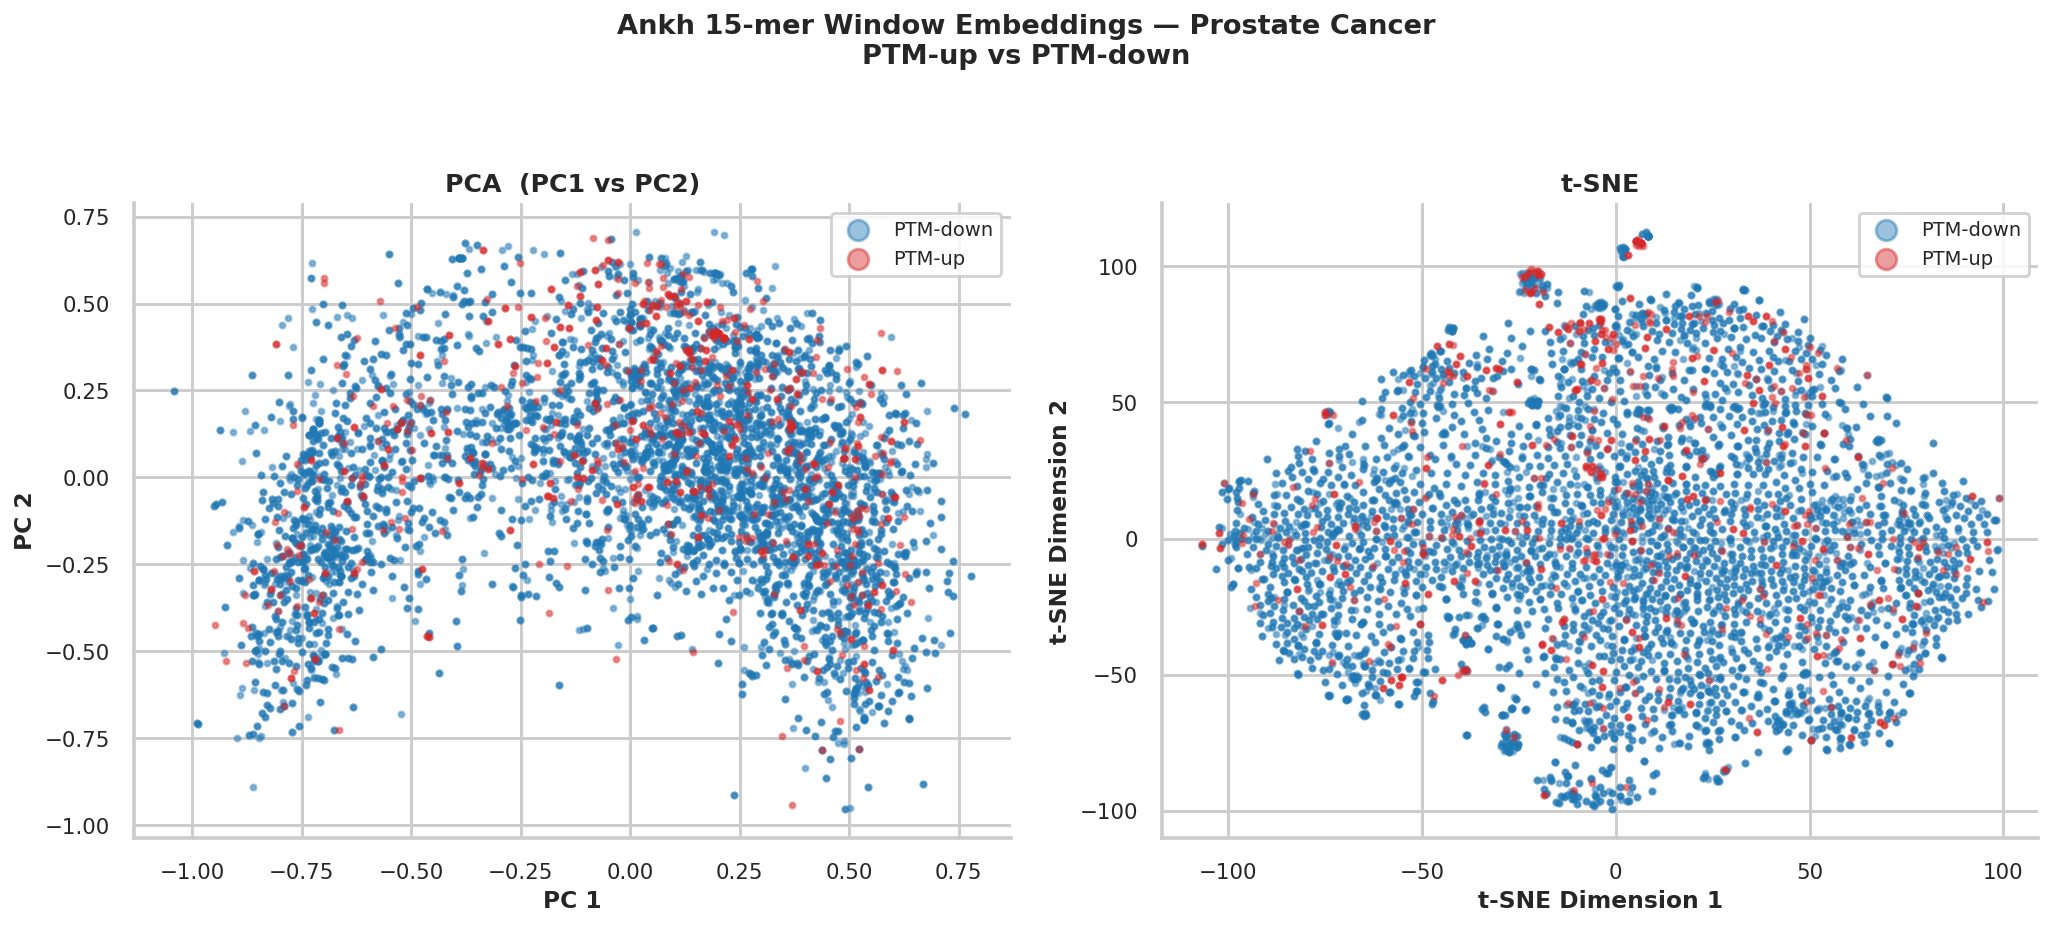

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/08_pca_tsne.png


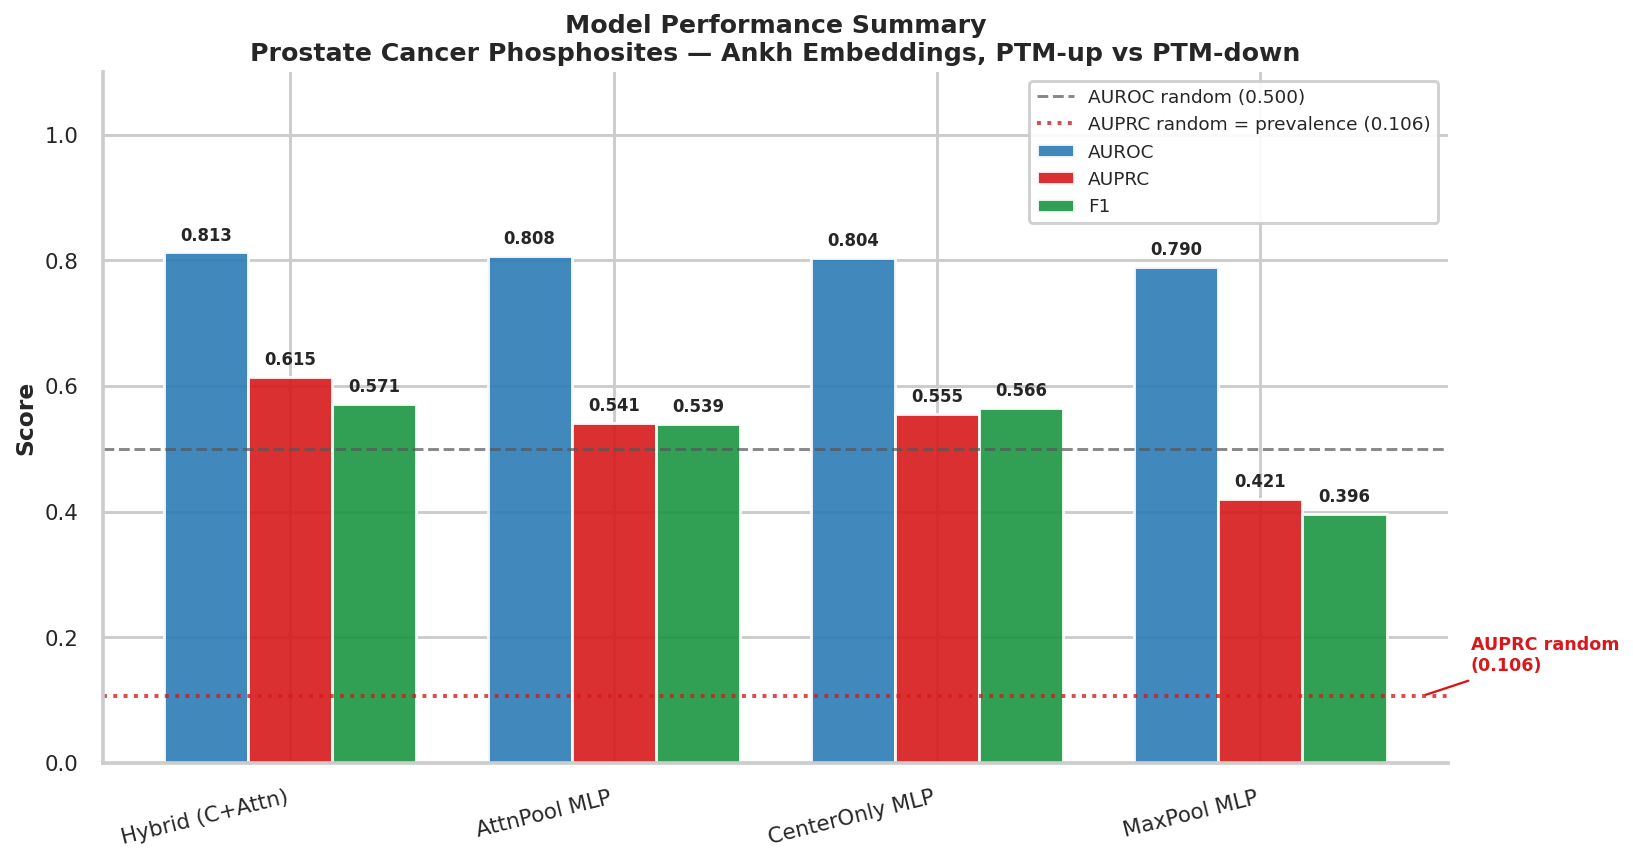

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/09_model_performance_summary.png


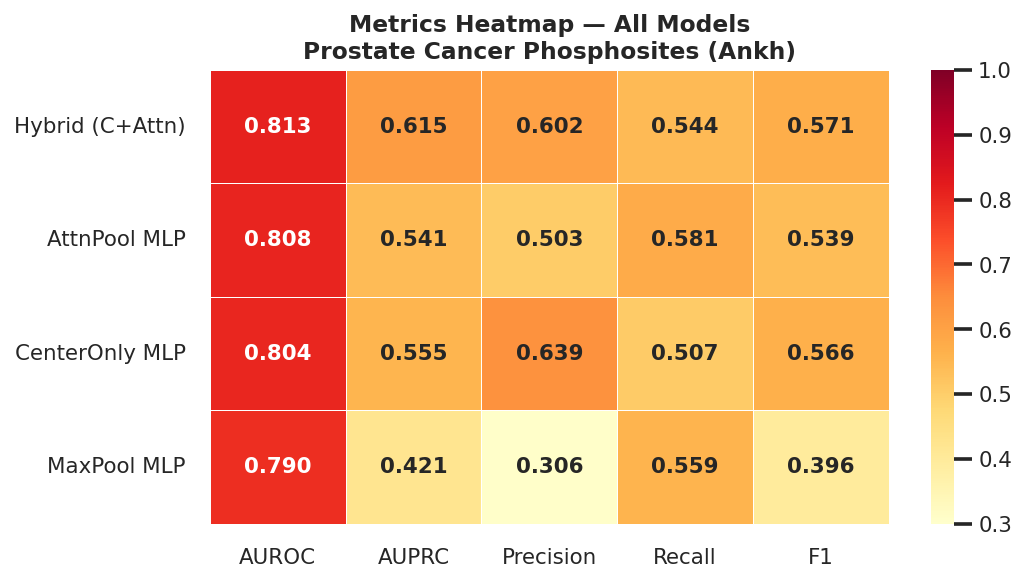

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/10_metrics_heatmap.png

  All publication figures saved to:
  /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh


In [13]:

# ════════════════════════════════════════════════════════════════════════════
# PUBLICATION-GRADE FIGURES  (numbering mirrors EGFR reference pipeline)
#    01 class_distribution | 04 central_residue | 05 roc_pr | 06 confusion
#    07 model_metrics_summary.csv | 08 pca_tsne | 09 perf_bar | 10 heatmap
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)

# ── Global publication style ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi":          140,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelweight":    "bold",
    "axes.titleweight":    "bold",
    "axes.titlesize":      13,
    "axes.labelsize":      12,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "legend.fontsize":     10,
    "savefig.bbox":        "tight",
    "savefig.dpi":         300,
})
PALETTE4 = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
RED, BLUE = "#d62728", "#1f77b4"
THRESHOLD = 0.5

# ── 07. Model Metrics CSV ─────────────────────────────────────────────────────
metrics_df.to_csv(RESULTS_DIR / "07_model_metrics_summary.csv", index=False)
print(f"Saved → {RESULTS_DIR / '07_model_metrics_summary.csv'}")

# ── 01. Class Distribution ────────────────────────────────────────────────────
n_up   = int((y == 1).sum())
n_down = int((y == 0).sum())
cc = pd.DataFrame({"Class": ["PTM-up (1)", "PTM-down (0)"], "Count": [n_up, n_down]})
cc["Fraction"] = cc["Count"] / cc["Count"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(cc["Class"], cc["Count"],
              color=[RED, BLUE], alpha=0.90, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Number of phosphosites")
ax.set_title("Class Distribution\nProstate Cancer Phosphosites (Palbociclib Response)")
ax.set_ylim(0, cc["Count"].max() * 1.20)
for i, row in cc.iterrows():
    ax.text(i, row["Count"] + cc["Count"].max() * 0.015,
            f'{row["Count"]:,}\n({row["Fraction"]:.1%})',
            ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '01_class_distribution.png'}")

# ── 04. Central Residue Composition ──────────────────────────────────────────
df_model["center_aa"] = df_model["Site_15mer"].apply(
    lambda s: str(s)[7] if isinstance(s, str) and len(s) >= 8 and str(s)[7] not in ("_", "-") else None
)
df_up_m   = df_model[df_model["Class"] == 1].dropna(subset=["center_aa"])
df_down_m = df_model[df_model["Class"] == 0].dropna(subset=["center_aa"])
aas       = sorted(set(df_up_m["center_aa"]) | set(df_down_m["center_aa"]))
up_freq   = df_up_m["center_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)
down_freq = df_down_m["center_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)

x = np.arange(len(aas))
width = 0.40
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, up_freq.values,   width, label="PTM-up",   color=RED,  alpha=0.88, edgecolor="white")
ax.bar(x + width / 2, down_freq.values, width, label="PTM-down", color=BLUE, alpha=0.88, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(aas)
ax.set_xlabel("Central residue at phosphosite")
ax.set_ylabel("Relative Frequency")
ax.set_title("Central Residue Composition at Phosphosites\nPTM-up vs PTM-down")
ax.legend(framealpha=0.85)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_central_residue_composition.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '04_central_residue_composition.png'}")

# ── 05. ROC + PR Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
baseline_pr = float((y_test == 1).mean())

for (name, res), color in zip(results.items(), PALETTE4):
    probs = res["probs"]
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, lw=2.4, color=color,
                 label=f"{name}  (AUROC = {res['roc_auc']:.3f})")
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec_c, prec_c, lw=2.4, color=color,
                 label=f"{name}  (AUPRC = {res['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1.4, alpha=0.55, label="Random  (AUROC = 0.500)")
axes[0].fill_between([0, 1], [0, 1], alpha=0.04, color="k")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Prostate Cancer (Ankh)\nPTM-up vs PTM-down")
axes[0].legend(loc="lower right", fontsize=9.5, framealpha=0.90)

axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", lw=1.4, alpha=0.55,
               label=f"Random  (PR = {baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Prostate Cancer (Ankh)\nPTM-up vs PTM-down")
axes[1].legend(loc="upper right", fontsize=9.5, framealpha=0.90)

fig.suptitle("Ankh 15-mer Window Classifiers — Prostate Cancer Phosphosites",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '05_roc_pr_curves.png'}")

# ── 06. Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, res), color in zip(axes, results.items(), PALETTE4):
    probs = res["probs"]
    preds = (probs >= THRESHOLD).astype(int)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["PTM-down (0)", "PTM-up (1)"],
        yticklabels=["PTM-down (0)", "PTM-up (1)"],
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 15, "weight": "bold"},
    )
    roc = res["roc_auc"]
    f1  = f1_score(y_test, preds, zero_division=0)
    ax.set_title(f"{name}\nAUROC = {roc:.3f}  |  F1 = {f1:.3f}", fontsize=10.5)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
fig.suptitle("Confusion Matrices  (threshold = 0.5) — Ankh",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '06_confusion_matrices.png'}")

# ── 08. PCA + t-SNE Embedding Visualisation ───────────────────────────────────
label_colors = {1: RED, 0: BLUE}
label_names  = {1: "PTM-up", 0: "PTM-down"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for label in [0, 1]:
    mask = y == label
    kw = dict(s=7, alpha=0.45, color=label_colors[label],
              label=label_names[label], rasterized=True)
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], **kw)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], **kw)

for ax, title, xl, yl in zip(
    axes,
    ["PCA  (PC1 vs PC2)", "t-SNE"],
    ["PC 1", "t-SNE Dimension 1"],
    ["PC 2", "t-SNE Dimension 2"],
):
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend(markerscale=4, framealpha=0.85)

fig.suptitle("Ankh 15-mer Window Embeddings — Prostate Cancer\nPTM-up vs PTM-down",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '08_pca_tsne.png'}")

# ── 09. Model Performance Summary (grouped bar + baselines) ───────────────────
auprc_random = float((y_test == 1).mean())
mp   = metrics_df.set_index("Model")[["AUROC", "AUPRC", "F1"]].copy()
xpos = np.arange(len(mp))
w    = 0.26
fig, ax = plt.subplots(figsize=(12, 6.5))
b1 = ax.bar(xpos - w, mp["AUROC"], w, label="AUROC", color="#2c7bb6", alpha=0.90, edgecolor="white")
b2 = ax.bar(xpos,     mp["AUPRC"], w, label="AUPRC", color="#d7191c", alpha=0.90, edgecolor="white")
b3 = ax.bar(xpos + w, mp["F1"],    w, label="F1",    color="#1a9641", alpha=0.90, edgecolor="white")
ax.axhline(0.500,        ls="--", lw=1.5, color="#555555", alpha=0.70,
           label="AUROC random (0.500)")
ax.axhline(auprc_random, ls=":",  lw=2.0, color="#d7191c", alpha=0.80,
           label=f"AUPRC random = prevalence ({auprc_random:.3f})")
ax.annotate(f"AUPRC random\n({auprc_random:.3f})",
            xy=(len(mp) - 0.5, auprc_random),
            xytext=(len(mp) - 0.35, auprc_random + 0.04),
            fontsize=9, color="#d7191c", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#d7191c", lw=1.2))
ax.set_xticks(xpos)
ax.set_xticklabels(mp.index, rotation=14, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.10)
ax.set_title("Model Performance Summary\nProstate Cancer Phosphosites — Ankh Embeddings, PTM-up vs PTM-down")
ax.legend(loc="upper right", framealpha=0.90, fontsize=9.5)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.013,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "09_model_performance_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '09_model_performance_summary.png'}")

# ── 10. Metrics Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
hm_data = metrics_df.set_index("Model")[["AUROC", "AUPRC", "Precision", "Recall", "F1"]]
sns.heatmap(
    hm_data, annot=True, fmt=".3f", cmap="YlOrRd",
    vmin=0.3, vmax=1.0, linewidths=0.5, linecolor="white",
    annot_kws={"size": 11, "weight": "bold"}, ax=ax,
)
ax.set_title("Metrics Heatmap — All Models\nProstate Cancer Phosphosites (Ankh)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "10_metrics_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '10_metrics_heatmap.png'}")

print(f"\n{'='*60}")
print(f"  All publication figures saved to:")
print(f"  {RESULTS_DIR}")
print(f"{'='*60}")


In [14]:
# ── HTML Summary Report (mirrors EGFR reference pipeline) ────────────────────
import base64
from pathlib import Path


def img_to_b64(path: Path) -> str:
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="max-width:100%;"/>'


plot_files   = sorted(RESULTS_DIR.glob("*.png"))
metrics_html = metrics_df.to_html(index=False, border=1,
                                   classes="metrics", justify="center")

html_parts = [
    f"""<!DOCTYPE html>
<html><head>
<meta charset='utf-8'/>
<title>Ankh Phospho Prostate Cancer — Analysis Report</title>
<style>
  body {{ font-family: Arial, sans-serif; max-width: 1100px; margin: auto; padding: 20px; }}
  h1   {{ color: #1a3c34; }}
  h2   {{ color: #2c3e50; border-bottom: 2px solid #ccc; padding-bottom: 4px; }}
  table.metrics {{ border-collapse: collapse; width: 100%; }}
  table.metrics th, table.metrics td {{ border: 1px solid #aaa; padding: 8px 14px; text-align: center; }}
  table.metrics th {{ background-color: #1a3c34; color: white; }}
  .plot-grid {{ display: flex; flex-wrap: wrap; gap: 16px; }}
  .plot-grid figure {{ margin: 0; text-align: center; }}
</style>
</head><body>
<h1>Ankh Prostate Cancer Phosphorylation Classifier</h1>
<h2>Dataset: LNCaP Cells — Palbociclib Response (PTM-up vs PTM-down)</h2>
<p><b>PTM-up (1):</b> {n_up} sites &nbsp;|&nbsp; <b>PTM-down (0):</b> {n_down} sites</p>
<p><b>Model:</b> Ankh-base ({EMBED_DIM}-dim) · 15-residue context window around phosphosite</p>
<hr/>
<h2>Model Performance Summary</h2>
""",
    metrics_html,
    "<hr/>\n<h2>Plots</h2>\n<div class='plot-grid'>\n",
]

for p in plot_files:
    html_parts.append(f"<figure>{img_to_b64(p)}<figcaption>{p.name}</figcaption></figure>\n")

html_parts.append("</div></body></html>")

report_path = RESULTS_DIR / "report_phospho_ankh.html"
report_path.write_text("".join(html_parts), encoding="utf-8")
print(f"HTML report saved → {report_path}")


HTML report saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/results_prostate_phospho_ankh/report_phospho_ankh.html


In [15]:
ls

CPTAC_PTM_intensity.csv
PMADS.xlsx
PTMD_data_in_pmads.txt
Prostate_Phospho_Ankh_pipeline.ipynb
Prostate_Phospho_ESM2_pipeline.ipynb
Prostate_Phospho_ProtT5_pipeline.ipynb
Whole_DB.zip
annotation.zip
data/
decryptM_data_in_pmads.txt
filtering_script.py
prostate_phosphorylation_lncap_palbociclib_analysis/
results_prostate_phospho_ankh/
results_prostate_phospho_esm2/
results_prostate_phospho_prott5/
